In [1]:
import os
import time
import umap
import yaml
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as datetime 
import matplotlib.pyplot as plt 
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset, default_collate

from mm_cgmvae import *
from train_mmvae import*
from VAE_model_architectures import*

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
params = {
    'general': {
'dataset': 'AD',  # DO
'model_type': 'CGMVAE', # VAE or CVAE or GMVAE 
'random_seed': 22, # 85 # 123 for same region
'learn_prior': False,
'accelerator': True,
'M': 2,
'epochs': 5,
'num_iwae_samples': 1, 
'learning_rate': 1e-3
    }
}

dataset = params['general']['dataset']
model_type = params['general']['model_type']
random_seed = params['general']['random_seed']
learn_prior = params['general']['learn_prior']
accelerator = params['general']['accelerator']
M = params['general']['M']
epochs = params['general']['epochs']
num_iwae_samples = params['general']['num_iwae_samples']
learning_rate = params['general']['learning_rate']

In [3]:
if dataset == 'AD':
    dataset_params = {
    'input_dim': [4842, 4850], # CHANGE BACK to 4841, 4841
    'H1': [128, 128], 
    'H2': [64, 64], 
    'H3': [32, 32],
    'latent_dim': 10,
    'batch_size': 271, # divided by length, 9751 / 971 leaves last batch = 271
    'scales': [1, 1],
    'dataset_abbrev': ['HC', 'PFC'], # CHANGE BACK 'HC1', 'HC2'
    'output_folder': '/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/test',
    #'input_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/sameregionhc_paired.csv',
    'input_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv',
    #'input_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/sampletest_hc_pfc_adbxd_paired.csv',
    'gmm_centers_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv',
    'gmm_std': 2,
    'num_classes': 4,
    'num_kl_samples': 100
    }
elif dataset == 'DO':
    dataset_params = {
    'input_dim': [5873, 36],
    'H1': [128, 35], 
    'H2': [64, 16], 
    'H3': [32, 10],
    'latent_dim': 10,
    'batch_size': 271, # divided by length, 9751 / 971 leaves last batch = 271
    'scales': [1, 1],
    'dataset_abbrev': ['Geno', 'Physio'],
    'output_folder': '/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/vanillavae4_genoreweighted_test',
    'input_path': '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio_cfc.csv',
    #'input_path': '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio.csv',
    'gmm_centers_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv',
    'gmm_std': 2,
    'num_classes': 4,
    'num_kl_samples': 100
    }
params['dataset_params'] = dataset_params
input_dim = params['dataset_params']['input_dim']
H1 = params['dataset_params']['H1']
H2 = params['dataset_params']['H2']
H3 = params['dataset_params']['H3']
latent_dim = params['dataset_params']['latent_dim']
batch_size = params['dataset_params']['batch_size']
scales = params['dataset_params']['scales']
dataset_abbrev = params['dataset_params']['dataset_abbrev']
output_folder = params['dataset_params']['output_folder']
input_path = params['dataset_params']['input_path']
gmm_centers_path = params['dataset_params']['gmm_centers_path']
gmm_std = params['dataset_params']['gmm_std']
num_classes = params['dataset_params']['num_classes']
num_kl_samples = params['dataset_params']['num_kl_samples']

In [4]:
# initialize device 
# set device to gpu if available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# create output folder 
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# save params in a yaml file 
with open(f"{output_folder}/config.yaml", "w") as f:
    yaml.dump(params, f)

In [5]:
# set seed
# np.random.seed(random_seed)
# torch.manual_seed(random_seed)
# torch.cuda.manual_seed_all(random_seed)
# # set seed
# os.environ["PYTHONHASHSEED"] = str(random_seed)
# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

# def set_seed(seed: int = random_seed):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False
#     torch.use_deterministic_algorithms(True)
# set_seed(random_seed)

In [5]:
def set_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
set_seed(random_seed)

In [6]:
def standardizer(input_array):
    mean = np.mean(input_array)
    std = np.std(input_array)
    return (input_array - mean)/std

def numpyToTensor(x):
    return torch.from_numpy(x)

In [7]:
class PairedDataset(Dataset):
    def __init__(self, paired_df, input_dims, label_col, cfm_col, dataset):
        self.paired_df = paired_df
        if dataset == 'AD':
            self.df1_layer1, self.x1, self.label1, self.cfm1, self.df2_layer1, self.x2, self.label2, self.cfm2 = load_pairedregion_data(paired_df, input_dims[0], input_dims[1], label_col, cfm_col)
        elif dataset == 'DO': 
            self.df1_layer1, self.x1, self.label1, self.cfm1, self.df2_layer1, self.x2, self.label2, self.cfm2 = load_pairedmodal_data(paired_df, input_dims[0], label_col, cfm_col)
        self.df1_layer1 = numpyToTensor(self.df1_layer1)
        self.x1 = numpyToTensor(self.x1)
        self.cfm1 = numpyToTensor(self.cfm1)
        self.label1 = numpyToTensor(self.label1)

        self.df2_layer1 = numpyToTensor(self.df2_layer1)
        self.x2 = numpyToTensor(self.x2)
        self.cfm2 = numpyToTensor(self.cfm2)
        self.label2 = numpyToTensor(self.label2)

    def __len__(self):
        return len(self.paired_df)
    def __getitem__(self, index):
        return (self.df1_layer1[index], self.x1[index], self.label1[index], self.cfm1[index]), (self.df2_layer1[index], self.x2[index], self.label2[index], self.cfm2[index])
    
def load_pairedregion_data(df, input_dim1, input_dim2, label_col, cfm_col):
    x1 = df[list(df.columns[0:input_dim1])].values.astype('float32')
    label1 = df[label_col].values
    cfm1 = df[cfm_col].values
    df1_layer1 = df[list(df.columns[0:input_dim1])].copy()
    df1_layer1['cfm'] = cfm1
    df1_layer1 = df1_layer1.values.astype('float32')

    x2 = df[list(df.columns[4852:4852+input_dim2])].values.astype('float32') # CHANGE back to df.columns[4851:4851+input_dim2]
    label2 = df[label_col].values
    cfm2 = df[cfm_col].values
    df2_layer1 = df[list(df.columns[4852:4852+input_dim2])].copy() # CHANGE BACK to df.columns[4851:4851+input_dim2]
    df2_layer1['cfm'] = cfm2
    df2_layer1 = df2_layer1.values.astype('float32')

    return df1_layer1, x1, label1, cfm1, df2_layer1, x2, label2, cfm2

def load_pairedmodal_data(df, input_dim1, label_col, cfm_col):
    x1 = df.iloc[:, 1:input_dim1+1].values.astype('float32')
    label1 = df[label_col].values
    cfm1 = df[cfm_col].values
    df1_layer1 = df.iloc[:, 1:input_dim1+1].copy()
    df1_layer1['cfm'] = cfm1
    df1_layer1 = df1_layer1.values.astype('float32')

    x2 = df.iloc[:, input_dim[0]+1:-5].values.astype('float32')
    label2 = df[label_col].values
    cfm2 = df[cfm_col].values
    df2_layer1 = df.iloc[:, input_dim[0]+1:-5].copy()
    df2_layer1['cfm'] = cfm2
    df2_layer1 = df2_layer1.values.astype('float32')

    return df1_layer1, x1, label1, cfm1, df2_layer1, x2, label2, cfm2

In [9]:
# will need to make dataloaders for DO dataset after I decide how to structure the model input

In [8]:
paired_df = pd.read_csv(input_path, low_memory=False)
if dataset == 'AD':
    label_col = '14-6-Bin_HC' # CHANGE BACK
    cfm_col = 'CFM_14_5_snRNA_HC' # CHANGE BACK
    paired_df[cfm_col] = standardizer(paired_df[cfm_col])
    #paired_df[cfm_col] = standardizer(paired_df[cfm_col])
    meta = {
            'strain': paired_df['strain'],
            '14-6-residual': paired_df['14-6-residual_HC'] # CHANGE BACK
        }
    paired_df_train = paired_df.sample(frac=1, random_state=random_seed)
    train_dataset = PairedDataset(paired_df_train, input_dim, label_col, cfm_col, dataset)
    test_dataset = PairedDataset(paired_df, input_dim, label_col, cfm_col, dataset)

    
elif dataset == 'DO':
    label_col = 'cfc_bin'
    cfm_col = 'CFC.24mo.Average'
    paired_df[cfm_col] = standardizer(paired_df[cfm_col])
    meta = {
        'mouse_id': paired_df['Mouse.ID'], 
        'diet': paired_df['Diet']
    } 
    paired_df_train = paired_df.sample(frac=1, random_state=random_seed)
    train_dataset = PairedDataset(paired_df_train, input_dim, label_col, cfm_col, dataset)
    test_dataset = PairedDataset(paired_df, input_dim, label_col, cfm_col, dataset)

In [11]:
# train_loader = DataLoader(train_dataset, batch_size=batch_size)
# test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

In [9]:
def _seed_worker(worker_id):
    worker_seed = random_seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(random_seed)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, worker_init_fn=_seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), num_workers=0, worker_init_fn=_seed_worker, generator=g)

In [10]:
if model_type == 'CGMVAE':
    gmm_centers = pd.read_csv(gmm_centers_path)
    gmm_centers = gmm_centers.iloc[:, 1:].T
    ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm_centers.values]).float().squeeze(), gmm_std, num_kl_samples)
    model = MM_CGMVAE(input_dim, H1, H2, H3, latent_dim, scales, num_classes, torch.tensor([gmm_centers.values]).float().squeeze(), gmm_std, ks_weight, cv_weight)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, amsgrad=False)

/tmp/ipykernel_1647231/483545983.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm_centers.values]).float().squeeze(), gmm_std, num_kl_samples)


In [14]:
ks_weight, cv_weight

(1366.721461954417, 0.016089454381010438)

In [11]:
# initialize loss vectors
total_loss = []
total_test_loss = []
test_epochs = []
individual_loss = {}
recon_loss = {}
mse_losses = {}
mse_cfm_losses = {}
for i, set in enumerate(dataset_abbrev): 
    individual_loss[set] = {}
    individual_loss[set]['lpx_z'] = []
    individual_loss[set]['kls'] = []
    recon_loss[set] = {}
    mse_losses[set] = {}
    mse_cfm_losses[set] =  {}
    if i ==  0:
        recon_loss[set][set] = []
        recon_loss[set][dataset_abbrev[i+1]] = []
        mse_losses[set][set] = []
        mse_losses[set][dataset_abbrev[i+1]] = []
        mse_cfm_losses[set][set] = []
        mse_cfm_losses[set][dataset_abbrev[i+1]] = []
    else:
        recon_loss[set][set] = []
        recon_loss[set][dataset_abbrev[i-1]] = []
        mse_losses[set][set] = []
        mse_losses[set][dataset_abbrev[i-1]] = []
        mse_cfm_losses[set][set] = []
        mse_cfm_losses[set][dataset_abbrev[i-1]] = []

In [37]:
start_time = time.time()
for epoch in range(1, epochs+1):
    loss, lpx_zs, kls, lpxz_ind, mse_loss, mse_cfm_loss = train(epoch, model, optimizer, train_loader, num_iwae_samples, device, epochs, model_type)
    print('one iteration done')
    total_loss.append(loss)
    for i, set in enumerate(dataset_abbrev): 
        individual_loss[set]['lpx_z'].append(lpx_zs[i]) 
        individual_loss[set]['kls'].append(kls[i])
        if i ==  0:
            recon_loss[set][set].append(lpxz_ind[0] / len(train_loader))
            recon_loss[set][dataset_abbrev[i+1]].append(lpxz_ind[1] / len(train_loader))
            mse_losses[set][set].append(mse_loss[0])
            mse_losses[set][dataset_abbrev[i+1]].append(mse_loss[1])
            mse_cfm_losses[set][set].append(mse_cfm_loss[0])
            mse_cfm_losses[set][dataset_abbrev[i+1]].append(mse_cfm_loss[1])
        else:
            recon_loss[set][set].append(lpxz_ind[3] / len(train_loader))
            recon_loss[set][dataset_abbrev[i-1]].append(lpxz_ind[2] / len(train_loader))
            mse_losses[set][set].append(mse_loss[3])
            mse_losses[set][dataset_abbrev[i-1]].append(mse_loss[2])
            mse_cfm_losses[set][set].append(mse_cfm_loss[3])
            mse_cfm_losses[set][dataset_abbrev[i-1]].append(mse_cfm_loss[2])
    if epoch in [epochs / 2, epochs]:
        test_epochs.append(epoch)
        test(epoch, model, optimizer, test_loader, num_iwae_samples, device, output_folder, dataset_abbrev, meta)
end_time = time.time()
print(str(end_time - start_time) + ' seconds for training/testing')

====> Epoch: 001 Train loss: 22007.0973
one iteration done
====> Epoch: 002 Train loss: 21376.1812
one iteration done
====> Epoch: 003 Train loss: 20149.0400
one iteration done
====> Epoch: 004 Train loss: 17897.5871
one iteration done
====> Epoch: 005 Train loss: 15654.5548
one iteration done
Encoded features from HC encoder saved
Encoded features from PFC encoder saved
Finished test reconstruction
Model saved
14.238260746002197 seconds for training/testing


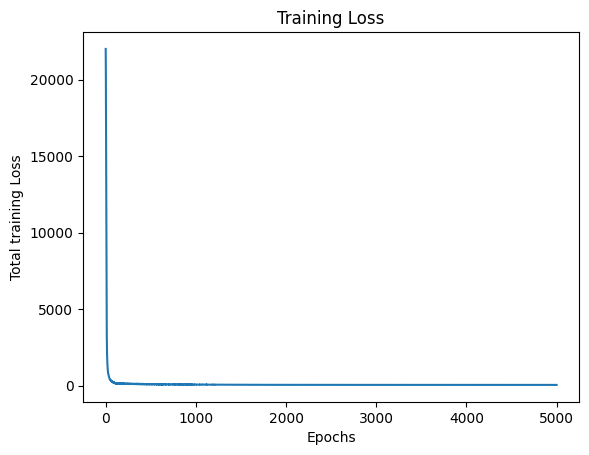

In [17]:
plt.figure()
plt.plot(total_loss, label='Training loss')                                                                          
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Total training Loss')            
plt.savefig(os.path.join(output_folder, 'train_loss.png'))

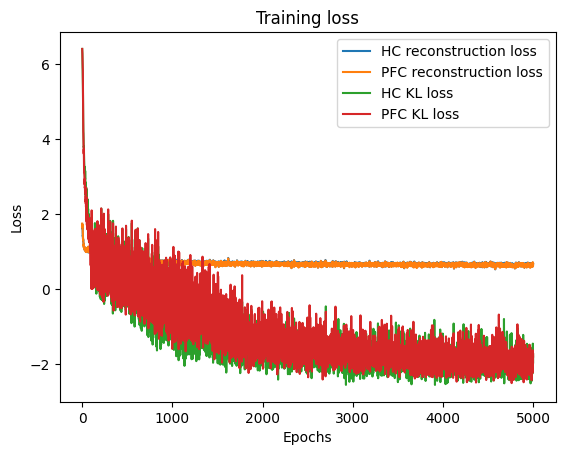

In [18]:
plt.figure()
names = ['reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        plt.plot(np.log(individual_loss[dataset_abbrev[j]][set]), label=f'{dataset_abbrev[j]} {names[i]}')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(os.path.join(output_folder, 'recon_kl_oneplot.png'))

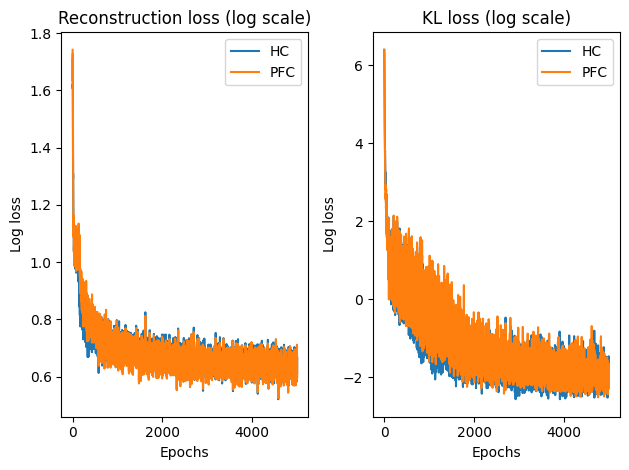

In [19]:
fig, ax = plt.subplots(1, 2)
names = ['Reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        ax[i].plot(np.log(individual_loss[dataset_abbrev[j]][set]), label=f'{dataset_abbrev[j]}')
    ax[i].set_title(f'{names[i]} (log scale)')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Log loss')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs_log.png'))

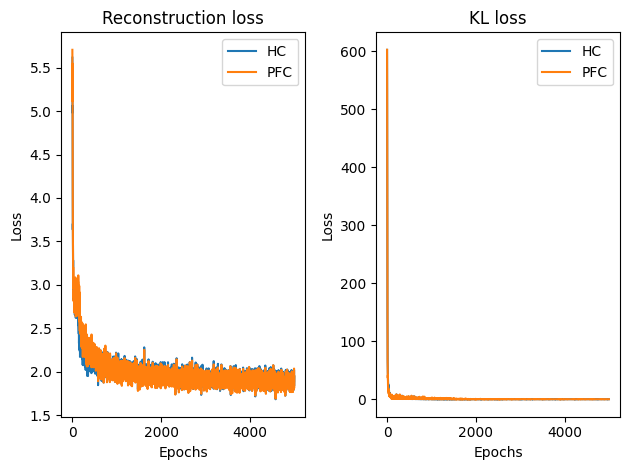

In [20]:
fig, ax = plt.subplots(1, 2)
names = ['Reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        ax[i].plot(individual_loss[dataset_abbrev[j]][set], label=f'{dataset_abbrev[j]}')
    ax[i].set_title(names[i])
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Loss')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs.png'))

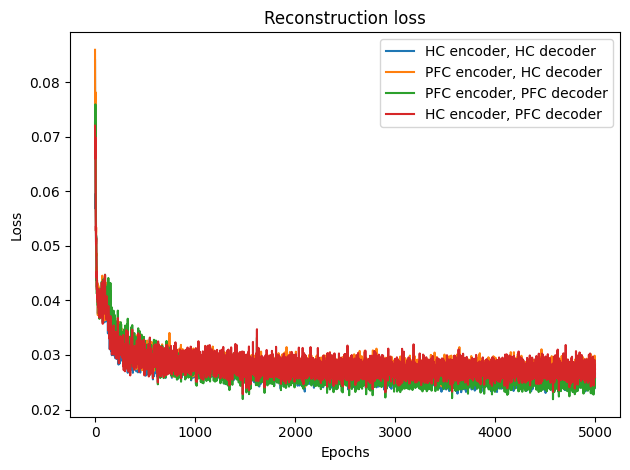

In [21]:
# Plotting each kind of reconstruction
for i, set in enumerate(dataset_abbrev):
    plt.plot((recon_loss[set][set]), label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((recon_loss[dataset_abbrev[i+1]][set]), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((recon_loss[dataset_abbrev[i-1]][set]), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Reconstruction loss')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_recon_loss_graphs.png'))

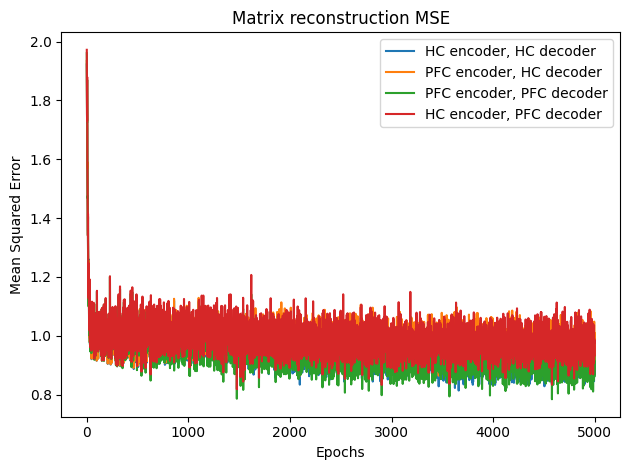

In [22]:
# Plotting each kind of reconstruction
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_losses[set][set], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_losses[dataset_abbrev[i+1]][set]), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_losses[dataset_abbrev[i-1]][set]), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Matrix reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_graphs.png'))

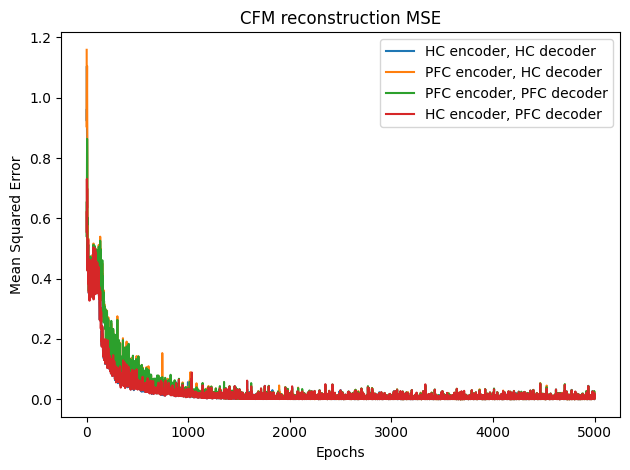

In [23]:
# Plotting each kind of reconstruction (cfm mse)
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_cfm_losses[set][set], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_cfm_losses[dataset_abbrev[i+1]][set]), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_cfm_losses[dataset_abbrev[i-1]][set]), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('CFM reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_cfm_graphs.png'))

Visualizing the latent space

In [49]:
hues=['encoder', 'bin']

In [25]:
latent_space_1 = latent_space_1 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_2 = latent_space_2 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[1]}.csv'), index_col=False)

In [26]:
latent_space_1.columns = latent_space_1.columns.str.replace(f'_{dataset_abbrev[0]}', '')
latent_space_2.columns = latent_space_2.columns.str.replace(f'_{dataset_abbrev[1]}', '')

In [27]:
latent_space_1

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual
0,-8.691865,-4.540180,2.589068,9.004190,13.732937,19.239714,26.107690,30.428919,38.338320,43.167507,3,1.243151,HC,124,1.277393
1,-8.998190,-4.841901,2.270128,8.716920,13.558518,18.899181,25.806873,29.896580,38.179237,42.910600,3,1.243151,HC,124,1.277393
2,-10.800984,-6.682497,0.500150,6.990326,11.939646,17.199420,24.193060,28.294968,36.648018,41.443050,3,1.243151,HC,124,1.277393
3,-7.751046,-3.582050,3.563764,10.030533,14.878817,20.264704,27.190310,31.380278,39.634357,44.292847,3,1.243151,HC,124,1.277393
4,-10.595372,-6.496790,0.771413,7.197690,11.996665,17.447256,24.373750,28.704520,36.726444,41.687004,3,1.243151,HC,124,1.277393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-23.790373,-16.876736,-16.740364,-10.136992,-4.548782,-3.380489,1.023346,4.446527,8.655209,13.611709,1,-0.215123,HC,28,-0.576731
9747,-23.557577,-17.048319,-16.239958,-9.988231,-4.000425,-3.006297,1.345907,5.590220,9.414691,14.483103,1,-0.215123,HC,28,-0.576731
9748,-23.312690,-16.573126,-16.348736,-9.782854,-4.132056,-3.122463,1.201700,4.793838,8.799282,13.663448,1,-0.215123,HC,28,-0.576731
9749,-22.046686,-15.378201,-14.686467,-7.659392,-1.020339,-0.580573,3.701427,7.297502,10.752717,16.050213,1,-0.215123,HC,28,-0.576731


In [28]:
latent_space_comb = pd.concat([latent_space_1, latent_space_2])
latent_space_comb = latent_space_comb.reset_index(drop=True)

In [17]:
prior_samples = pd.DataFrame(samples)
prior_samples['components'] = components

<Axes: xlabel='LV1', ylabel='Density'>

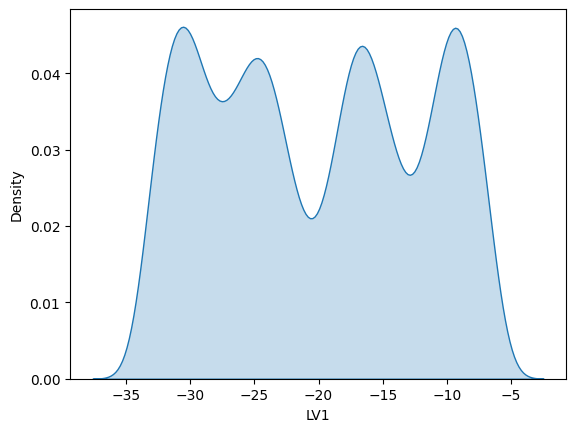

In [30]:
sns.kdeplot(data=latent_space_comb['LV1'], fill=True)

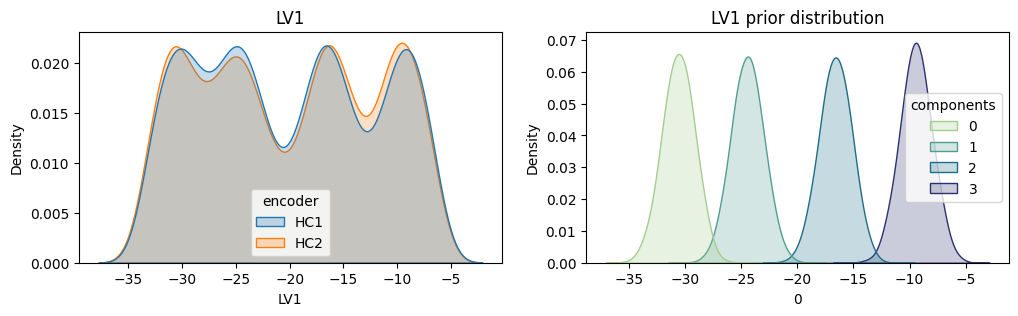

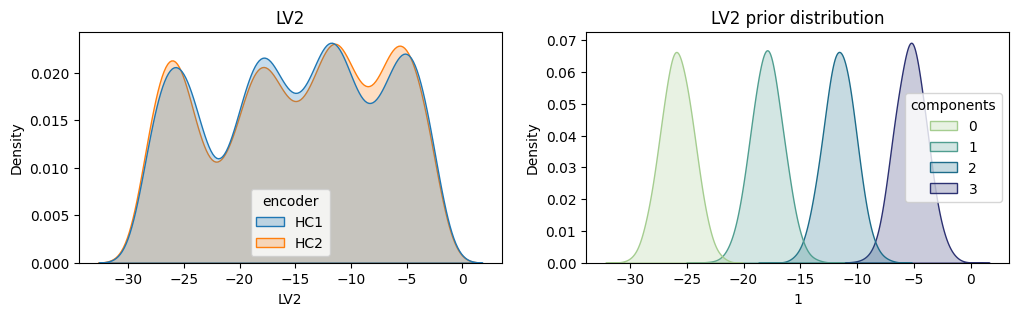

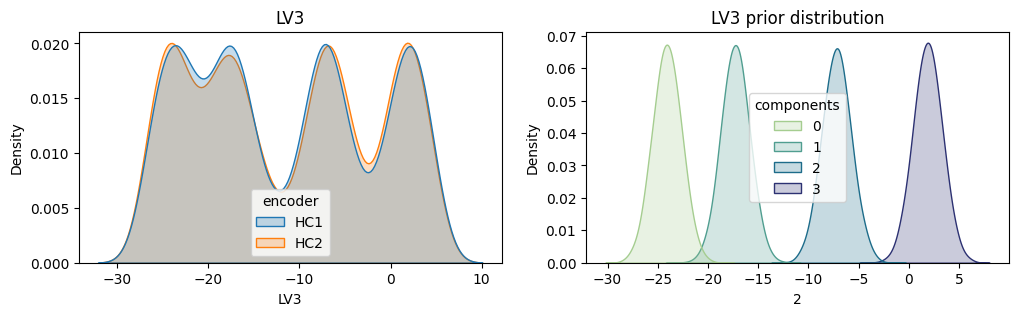

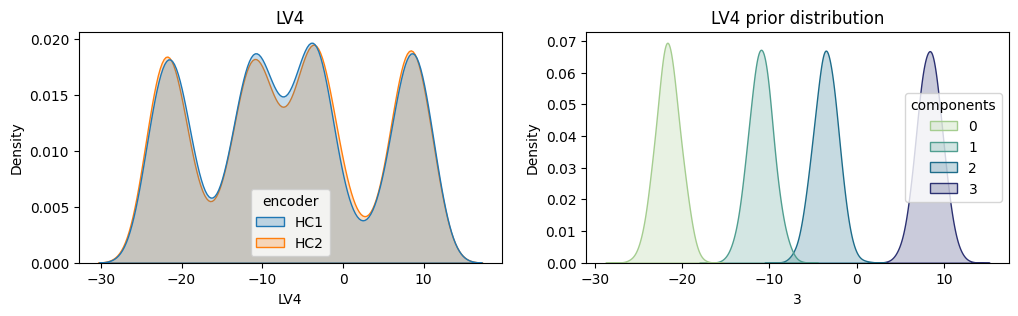

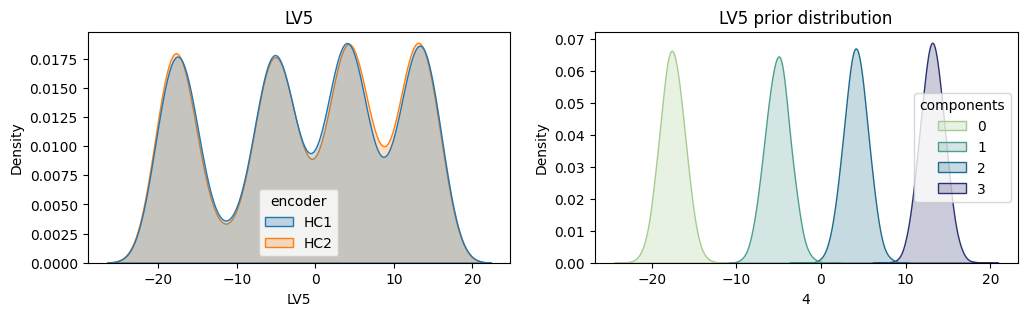

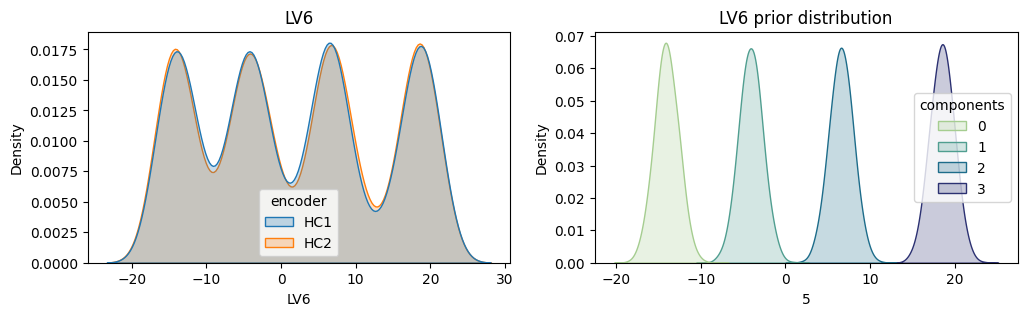

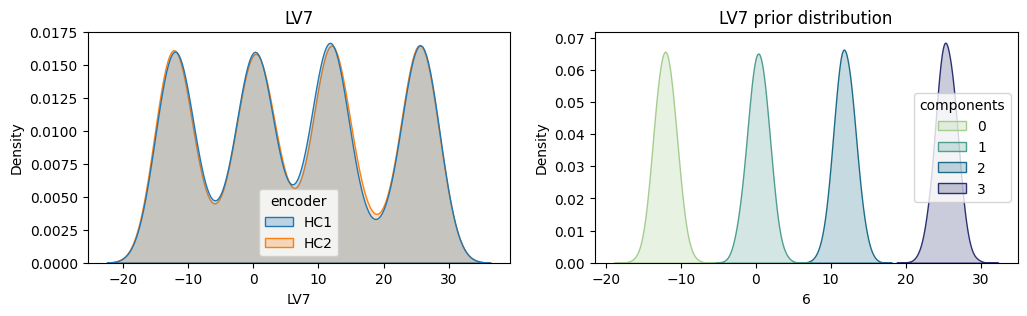

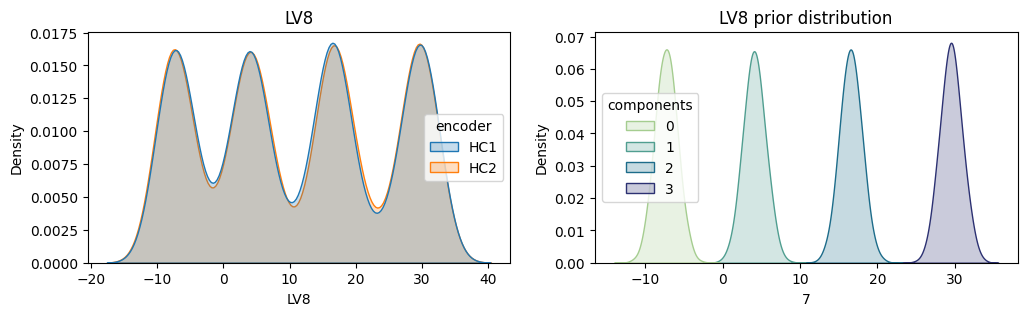

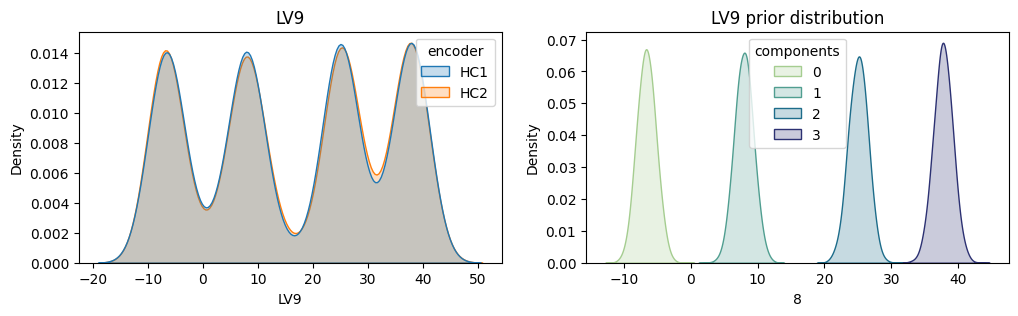

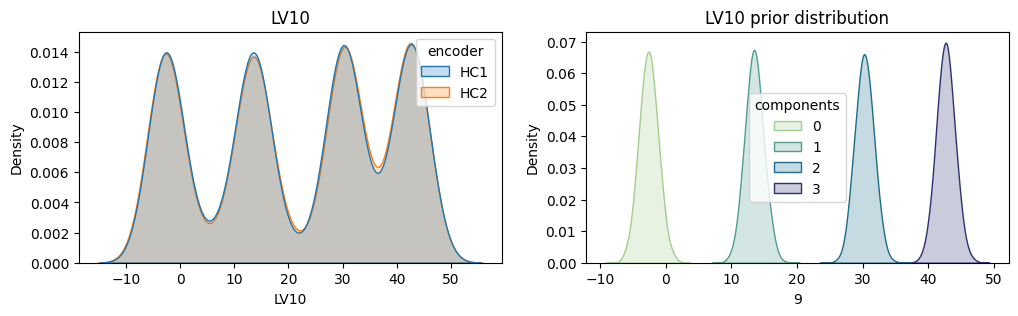

In [22]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'encoder']], x=column, hue='encoder', fill=True, bw_adjust=1, ax=ax[0])
    ax[0].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

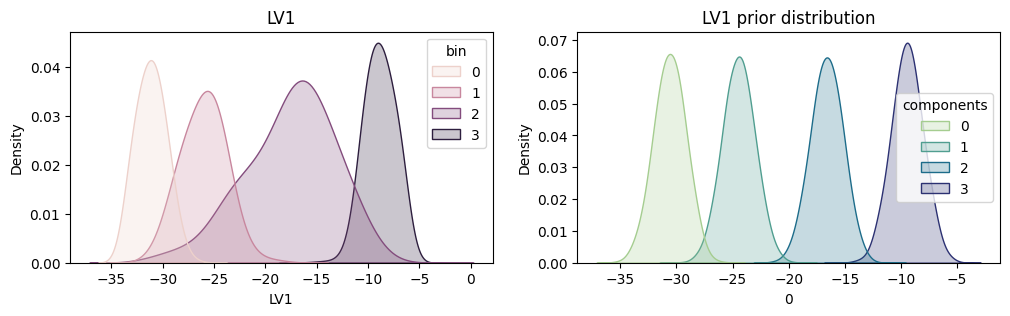

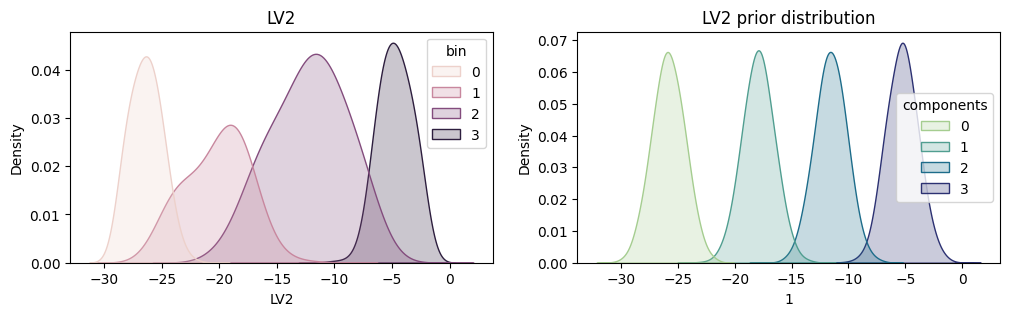

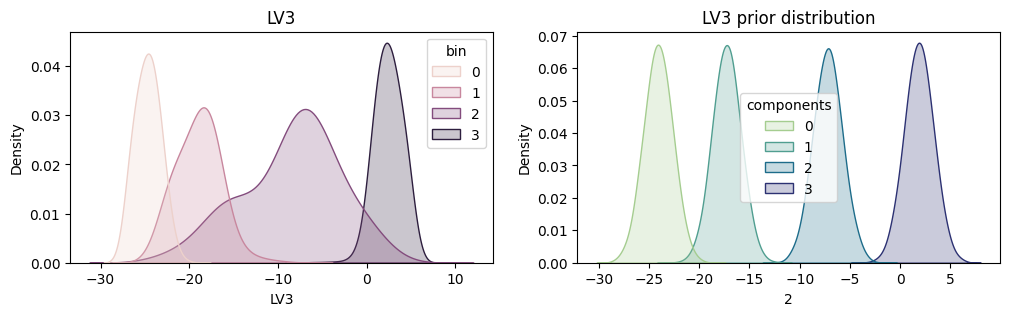

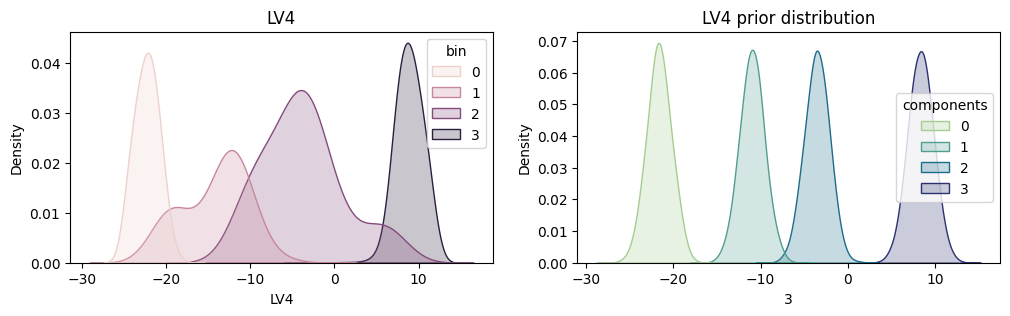

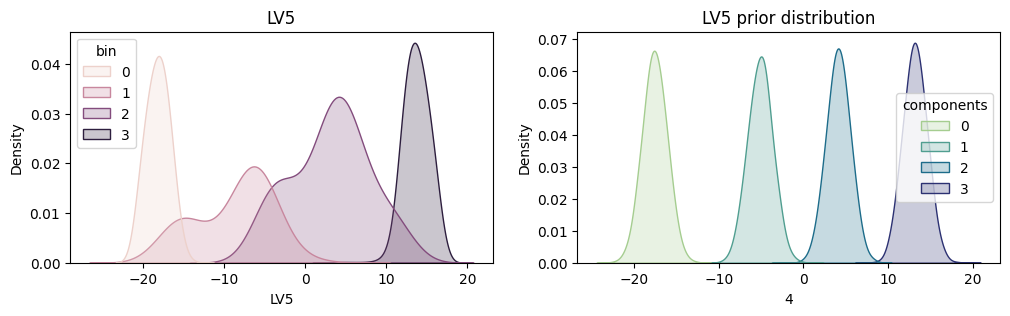

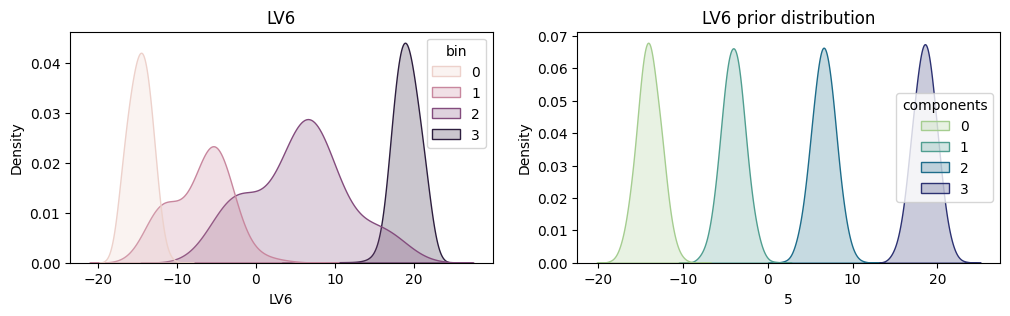

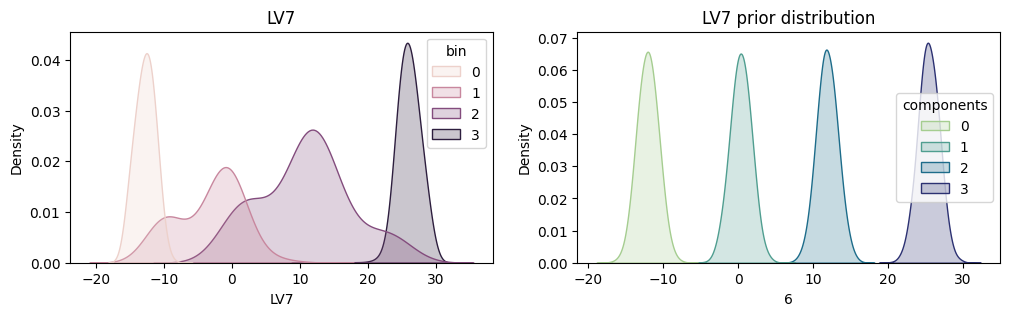

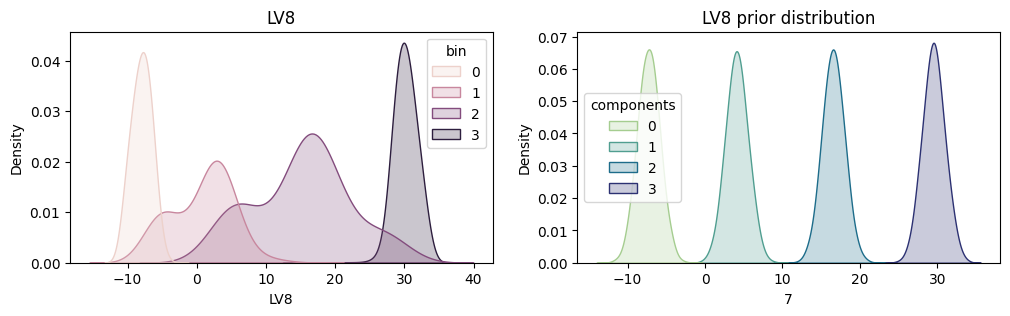

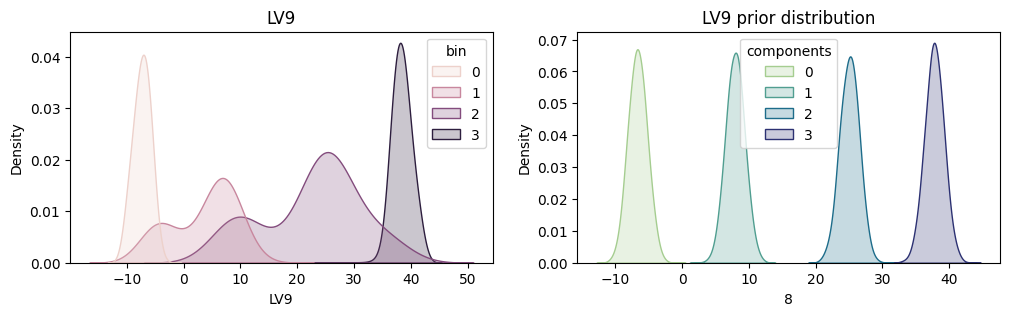

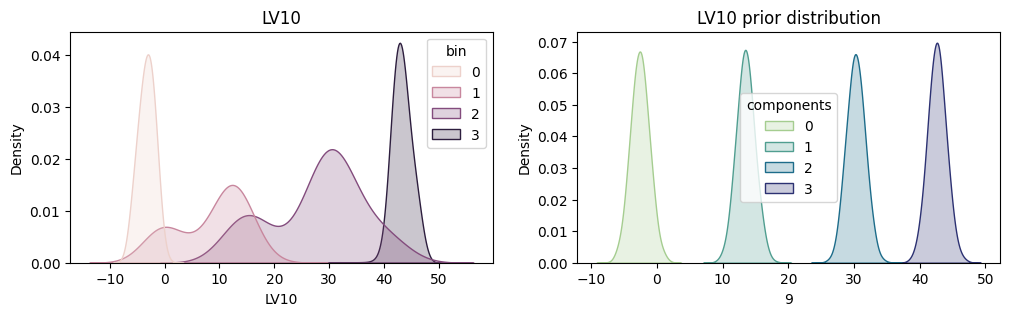

In [23]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'bin']], x=column, hue='bin', fill=True, bw_adjust=3, ax=ax[0])
    ax[0].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

In [24]:
latent_space_comb['bin_enc'] = latent_space_comb['bin'].astype(str) + '_' +  latent_space_comb['encoder']

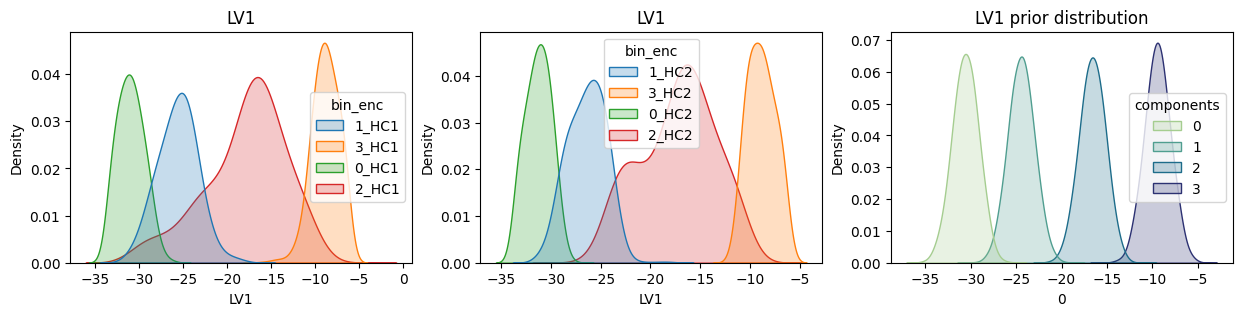

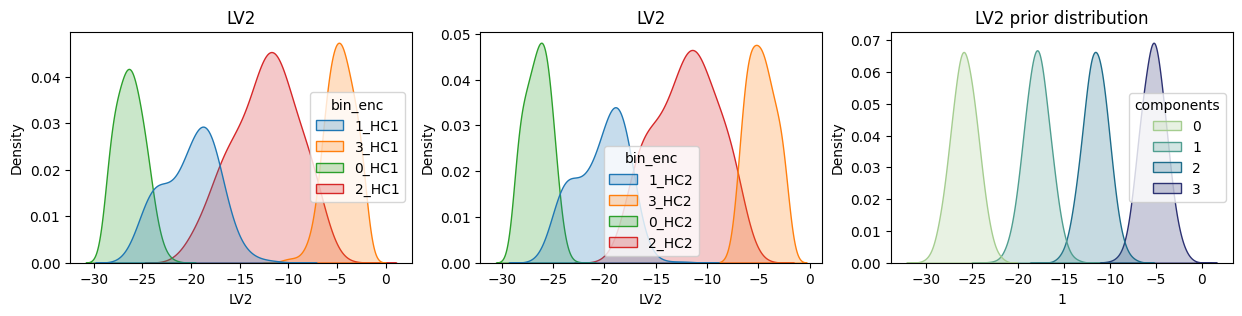

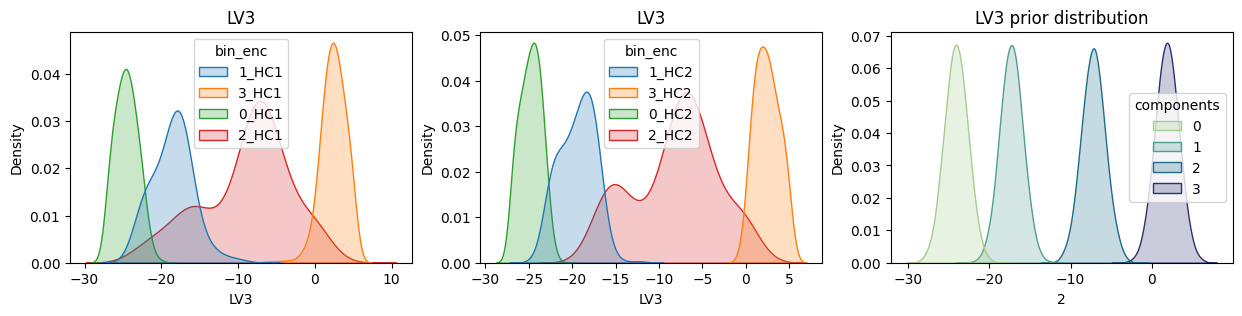

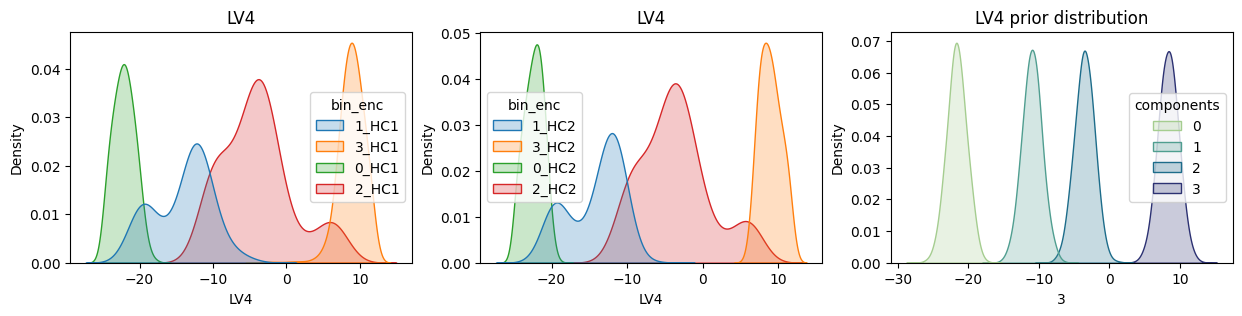

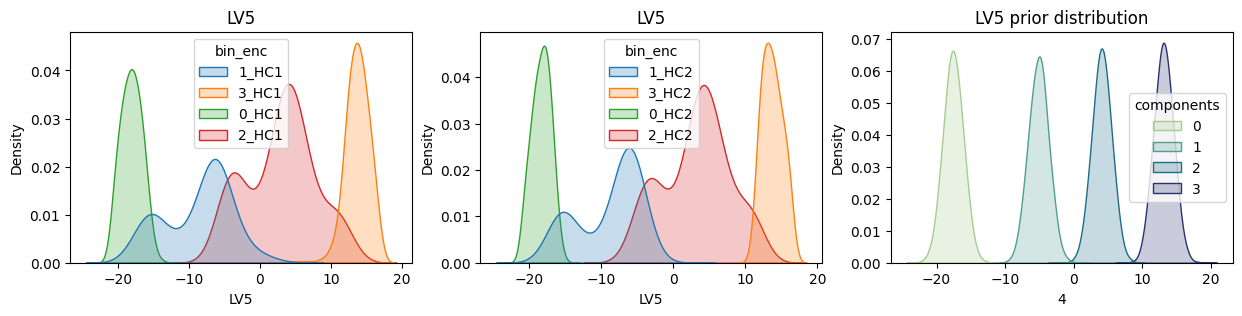

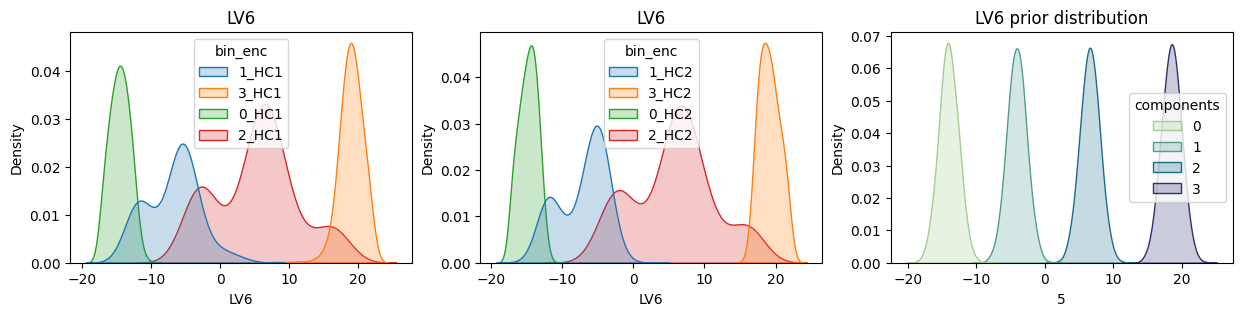

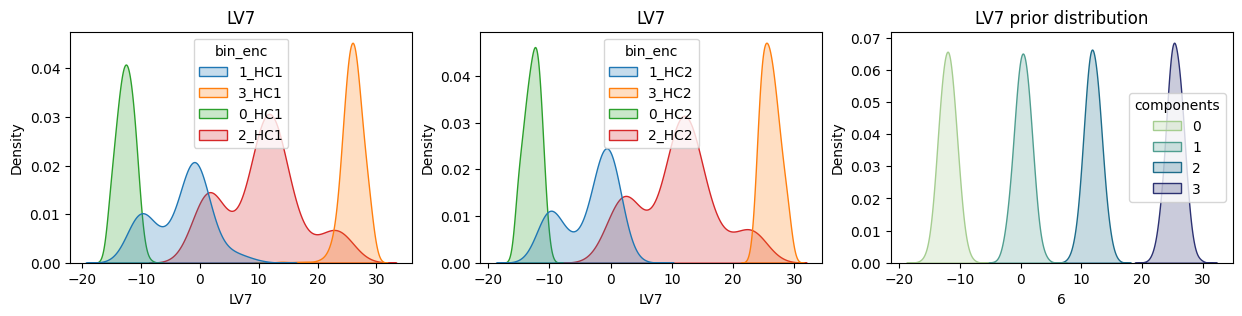

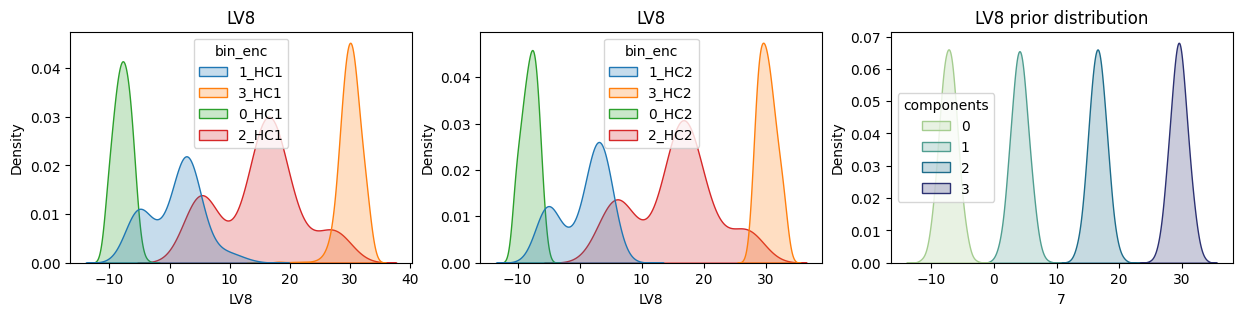

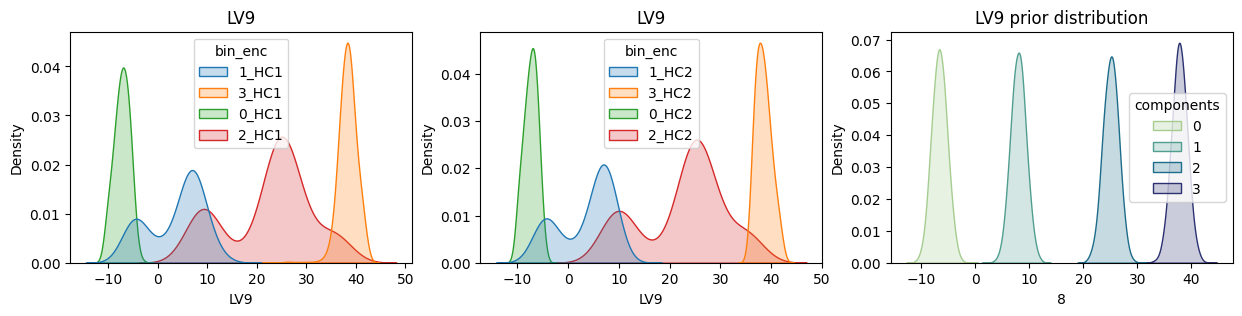

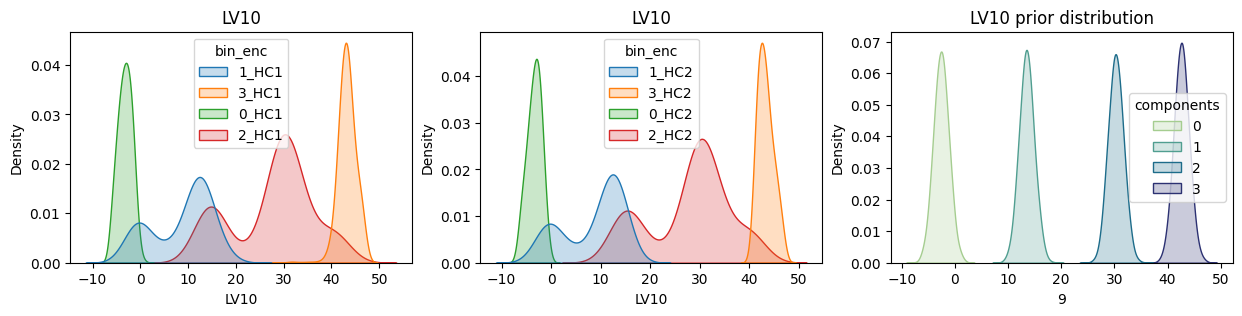

In [25]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    hc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[0])]
    sns.kdeplot(data=hc[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[0])
    ax[0].set_title(column)
    pfc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[1])]
    sns.kdeplot(data=pfc[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
    ax[2].set_title(f'{column} prior distribution')

In [26]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(latent_space_comb.iloc[:, :latent_dim])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [28]:
hues = ['encoder', 'bin']

In [29]:
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]

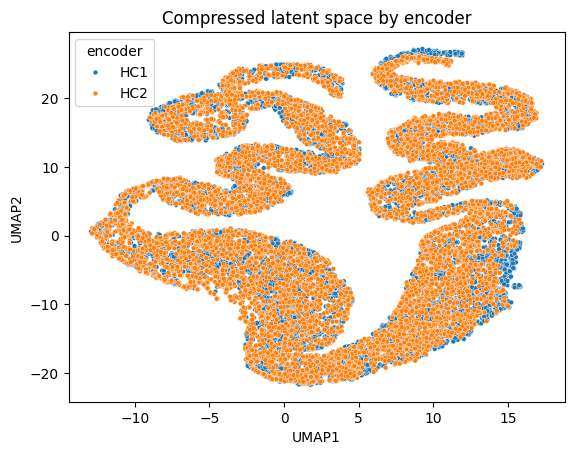

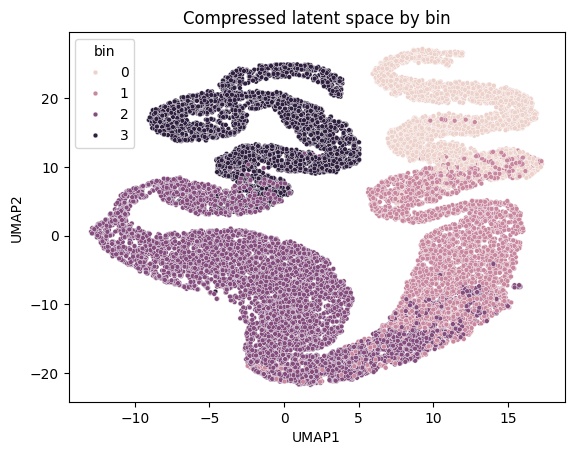

In [30]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

In [38]:
tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed)
tsne_embeddings = tsne.fit_transform(latent_space_comb.iloc[:, :latent_dim])
tsne_embedding_df = pd.DataFrame(tsne_embeddings, columns=['t-SNE1', 't-SNE2'])
for hue in hues: 
    tsne_embedding_df[hue] = latent_space_comb[hue]

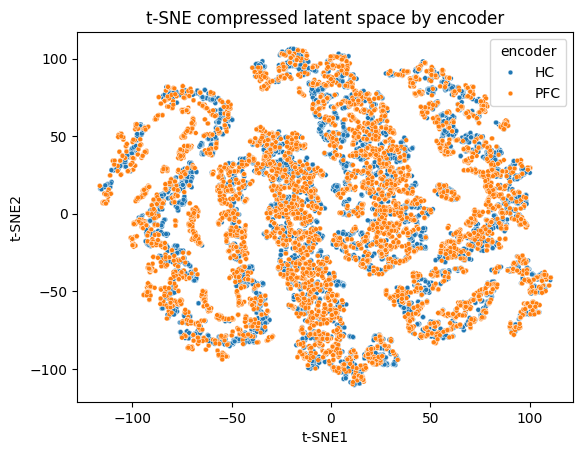

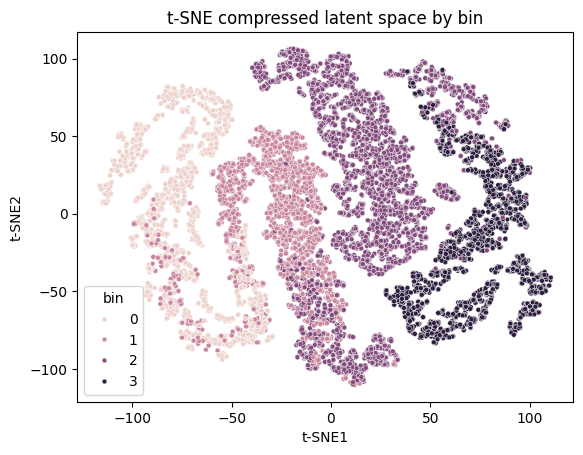

In [ ]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='t-SN
    
    
    
    
    
    
    
    
    
    ' \
    '
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    E1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12)
    plt.title(f't-SNE compressed latent space by {hue}')

Calculate and plot phenotypic projection

Latent space f-statistics

In [60]:
latent_space_PFC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/multiregion_seed22/latent_variables_epoch5000_vaePFC.csv')
latent_space_PFC

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual
0,-8.928140,-4.809561,2.281683,8.753087,13.460999,18.884504,25.644135,29.736480,37.868610,42.516680,3,1.243151,PFC,124,1.277393
1,-8.397496,-4.358115,2.684487,8.946035,13.731615,18.907774,25.604267,29.686703,37.705600,42.191230,3,1.243151,PFC,124,1.277393
2,-10.250976,-6.009866,1.158157,7.546812,12.581457,17.781584,24.750854,28.902996,37.263306,42.026370,3,1.243151,PFC,124,1.277393
3,-8.040747,-3.925632,3.210993,9.524192,14.499397,19.756027,26.710587,30.921250,39.215214,43.761307,3,1.243151,PFC,124,1.277393
4,-8.920031,-4.795441,2.310251,8.860720,13.547449,19.031300,25.827670,29.942518,38.130410,42.791440,3,1.243151,PFC,124,1.277393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-24.118921,-17.538810,-16.877668,-10.510710,-4.843801,-3.568205,0.518527,4.192939,8.334845,13.200276,1,-0.215123,PFC,28,-0.576731
9747,-25.085825,-18.538730,-17.829666,-11.452113,-5.626342,-4.553568,-0.103210,4.233789,7.866274,12.856388,1,-0.215123,PFC,28,-0.576731
9748,-24.772213,-17.920038,-17.200146,-10.840499,-5.013076,-3.661079,0.400508,3.921176,8.276760,12.666868,1,-0.215123,PFC,28,-0.576731
9749,-25.133146,-18.155617,-17.675552,-11.128118,-5.036339,-4.146335,0.392845,4.216240,8.034594,13.026533,1,-0.215123,PFC,28,-0.576731


In [61]:
latent_space_HC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/multiregion_seed22/latent_variables_epoch5000_vaeHC.csv')
latent_space_HC

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual
0,-8.691865,-4.540180,2.589068,9.004190,13.732937,19.239714,26.107690,30.428919,38.338320,43.167507,3,1.243151,HC,124,1.277393
1,-8.998190,-4.841901,2.270128,8.716920,13.558518,18.899181,25.806873,29.896580,38.179237,42.910600,3,1.243151,HC,124,1.277393
2,-10.800984,-6.682497,0.500150,6.990326,11.939646,17.199420,24.193060,28.294968,36.648018,41.443050,3,1.243151,HC,124,1.277393
3,-7.751046,-3.582050,3.563764,10.030533,14.878817,20.264704,27.190310,31.380278,39.634357,44.292847,3,1.243151,HC,124,1.277393
4,-10.595372,-6.496790,0.771413,7.197690,11.996665,17.447256,24.373750,28.704520,36.726444,41.687004,3,1.243151,HC,124,1.277393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-23.790373,-16.876736,-16.740364,-10.136992,-4.548782,-3.380489,1.023346,4.446527,8.655209,13.611709,1,-0.215123,HC,28,-0.576731
9747,-23.557577,-17.048319,-16.239958,-9.988231,-4.000425,-3.006297,1.345907,5.590220,9.414691,14.483103,1,-0.215123,HC,28,-0.576731
9748,-23.312690,-16.573126,-16.348736,-9.782854,-4.132056,-3.122463,1.201700,4.793838,8.799282,13.663448,1,-0.215123,HC,28,-0.576731
9749,-22.046686,-15.378201,-14.686467,-7.659392,-1.020339,-0.580573,3.701427,7.297502,10.752717,16.050213,1,-0.215123,HC,28,-0.576731


In [62]:
latent_space_comb = pd.concat([latent_space_PFC, latent_space_HC])
latent_space_comb = latent_space_comb.reset_index()
latent_space_comb = latent_space_comb.iloc[:, 1:]

In [63]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

le = LabelEncoder()
y = le.fit_transform(latent_space_comb['encoder'])
y

array([1, 1, 1, ..., 0, 0, 0])

In [64]:
latent_dim=10
dataset_abbrev = ['HC', 'PFC']

In [65]:
f_values, p_values = f_classif(latent_space_comb.iloc[:, :latent_dim], y)
latents_ordered = np.argsort(f_values)[::-1]
latents_ordered

array([5, 3, 7, 6, 4, 8, 9, 2, 1, 0])

In [66]:
latent_cols = latent_space_comb.iloc[:, :latent_dim].columns 
print('Latent feature variance correlations with encoder classification')
for col in latents_ordered:
    print(f'{latent_cols[col]}: {f_values[col], p_values[col]}')

Latent feature variance correlations with encoder classification
LV6: (0.29246510017144095, 0.5886513267323951)
LV4: (0.2896097899705595, 0.5904768367024638)
LV8: (0.2578687449607047, 0.6115938942858089)
LV7: (0.24259993251337714, 0.6223401261280131)
LV5: (0.21484593489138268, 0.6430006092610212)
LV9: (0.1409514247100615, 0.7073410770363788)
LV10: (0.12023939278696251, 0.7287787353781576)
LV3: (0.10115613024877355, 0.7504500249590594)
LV2: (0.06305960558575864, 0.8017265175454754)
LV1: (0.00992765534412133, 0.9206330501190867)


In [33]:
fclass_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'f_values': f_values,
    'p_values': p_values
}).sort_values(by='f_values', ascending=False)
fclass_importance_df

,Latent variable,f_values,p_values
0,LV1,0.273123,0.601251
3,LV4,0.233483,0.628960
2,LV3,0.232357,0.629788
5,LV6,0.134760,0.713551
1,LV2,0.127270,0.721284
4,LV5,0.115659,0.733795
8,LV9,0.098225,0.753974
9,LV10,0.093228,0.760117
6,LV7,0.065454,0.798078
7,LV8,0.051758,0.820035


SVM to predict features relevant to encoder classification

In [34]:
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

In [15]:
rbf_model = SVC(kernel='rbf')
rbf_model.fit(latent_space_comb.iloc[:, :latent_dim], y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
results = permutation_importance(rbf_model, latent_space_comb.iloc[:, :latent_dim], y, n_repeats=10, random_state=random_seed)

In [ ]:
rbf_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': results.importances_mean, 
    'Abs_weight': abs(results.importances_mean)
}).sort_values(by='Abs_weight', ascending=False)
rbf_importance_df
rbf_importance_df.to_csv(os.path.join(output_folder, 'rbf_svm_weights.csv'))

,Latent variable,Weight,Abs_weight
0,LV1,0.005779,0.005779
2,LV3,0.004991,0.004991
7,LV8,0.003825,0.003825
8,LV9,0.003413,0.003413
9,LV10,0.003407,0.003407
3,LV4,0.003113,0.003113
1,LV2,0.003054,0.003054
6,LV7,0.002584,0.002584
5,LV6,0.001760,0.001760
4,LV5,-0.001530,0.001530


In [20]:
for i in results.importances_mean.argsort()[::-1]:
    print(f"{latent_cols[i]}: {results.importances_mean[i]:.4f}")

LV1: 0.0058
LV3: 0.0050
LV8: 0.0038
LV9: 0.0034
LV10: 0.0034
LV4: 0.0031
LV2: 0.0031
LV7: 0.0026
LV6: 0.0018
LV5: -0.0015


In [35]:
# with linear kernel 
linear_model = SVC(kernel='linear')
linear_model.fit(latent_space_comb.iloc[:, :latent_dim], y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
weights = linear_model.coef_[0]
importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': weights, 
    'Abs_weight': abs(weights)
}).sort_values(by='Abs_weight', ascending=False)
importance_df.to_csv(os.path.join(output_folder, 'linear_svm_weights.csv'))

,Latent variable,Weight,Abs_weight
5,LV6,2.618659,2.618659
7,LV8,-2.249664,2.249664
6,LV7,-1.611702,1.611702
1,LV2,-1.162655,1.162655
3,LV4,0.971157,0.971157
4,LV5,0.762640,0.762640
8,LV9,0.580440,0.580440
2,LV3,0.501981,0.501981
0,LV1,-0.393039,0.393039
9,LV10,-0.020715,0.020715


Generate correlation plots between latent variables

In [73]:
from itertools import product

In [42]:
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual,bin_enc
0,-28.141718,-24.007244,-21.765528,-19.573574,-15.436902,-11.935094,-10.015207,-5.199206,-4.611480,-0.624497,1,-1.291204,HC1,D2,-0.673075,1_HC1
1,-26.622925,-20.714293,-19.456356,-13.612125,-7.531168,-6.633964,-1.986414,1.932367,5.909874,11.363714,1,-1.291204,HC1,D2,-0.673075,1_HC1
2,-24.604956,-18.824230,-17.431496,-12.319512,-6.448473,-5.407567,-0.969166,2.734672,6.713495,12.364059,1,-1.291204,HC1,D2,-0.673075,1_HC1
3,-22.973347,-17.093330,-15.402448,-9.773524,-3.763084,-2.478963,1.891219,5.868982,9.380153,14.932029,1,-1.291204,HC1,D2,-0.673075,1_HC1
4,-28.682787,-24.524096,-22.401672,-20.201610,-16.158253,-12.512776,-10.474367,-5.797189,-5.488271,-1.193665,1,-1.291204,HC1,D2,-0.673075,1_HC1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16987,-27.675474,-18.937775,-19.107021,-12.614828,-6.556158,-5.229839,-0.688657,3.404320,7.502855,12.798530,1,-0.207663,HC2,28,-0.576731,1_HC2
16988,-29.514135,-23.041914,-22.048280,-20.149012,-16.040220,-12.528246,-10.440641,-5.712052,-4.573348,-0.680018,1,-0.207663,HC2,28,-0.576731,1_HC2
16989,-30.242105,-24.869080,-22.948448,-20.091850,-16.015102,-12.404319,-10.577059,-5.313858,-4.697428,-1.063888,1,-0.207663,HC2,28,-0.576731,1_HC2
16990,-30.078897,-24.128240,-22.974636,-20.762262,-16.714909,-13.137954,-11.060838,-6.243441,-5.308547,-1.220176,1,-0.207663,HC2,28,-0.576731,1_HC2


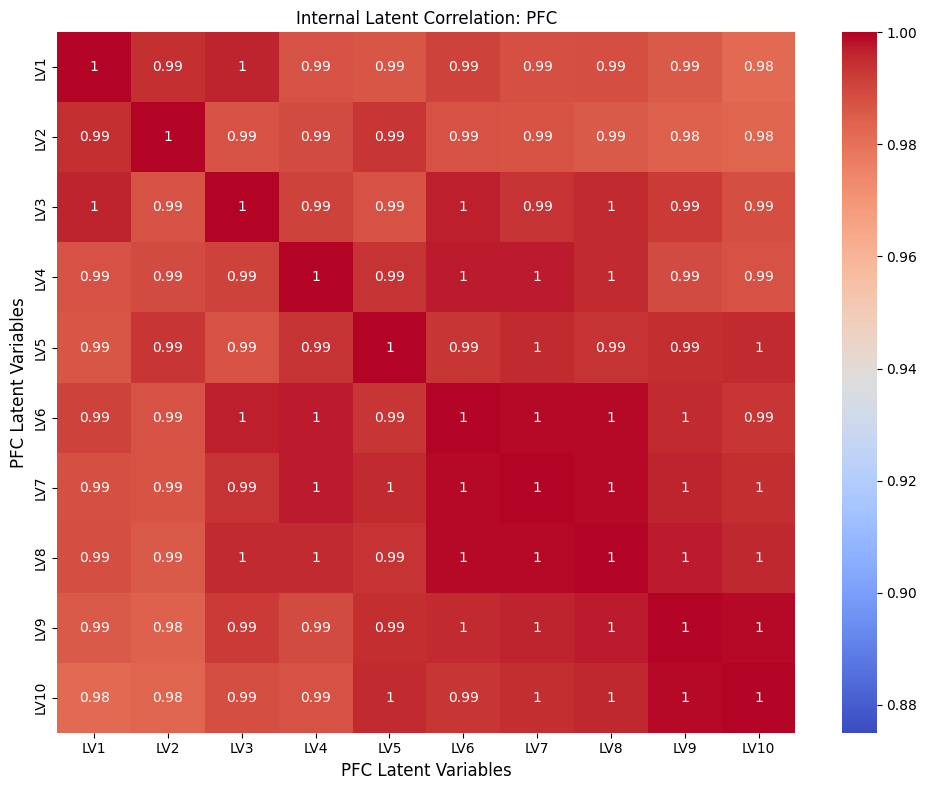

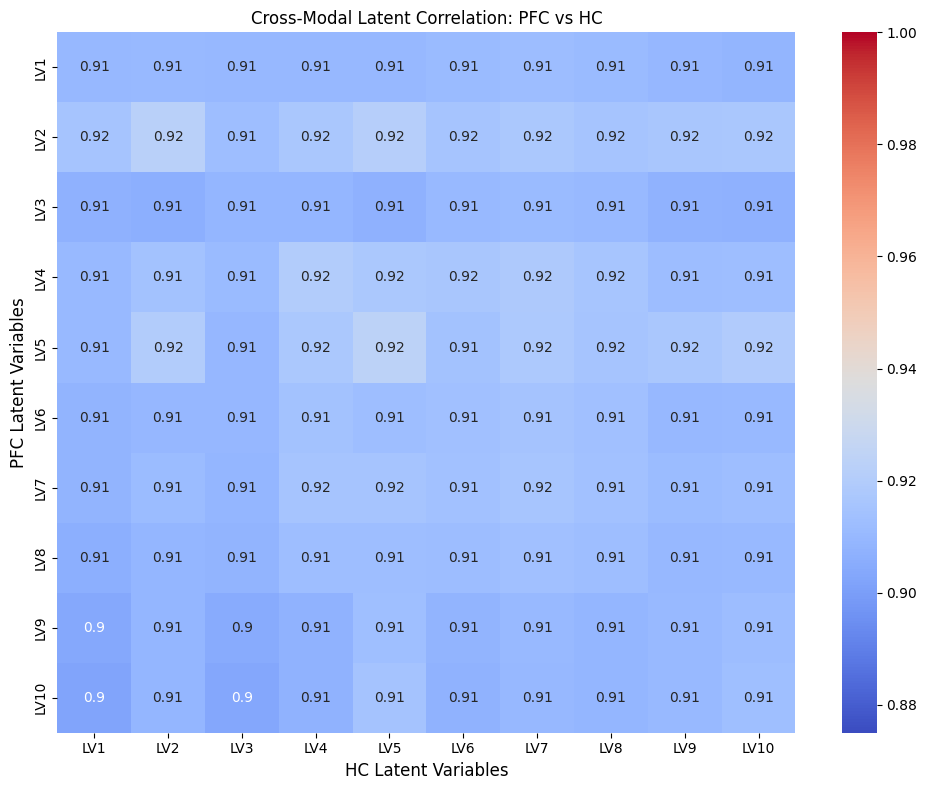

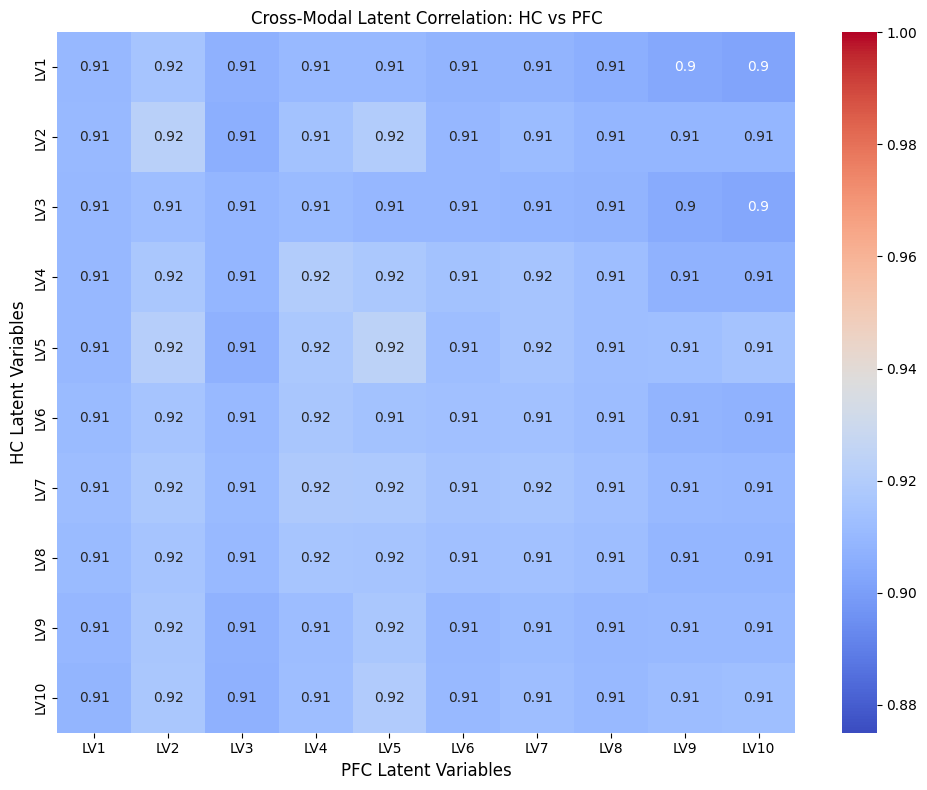

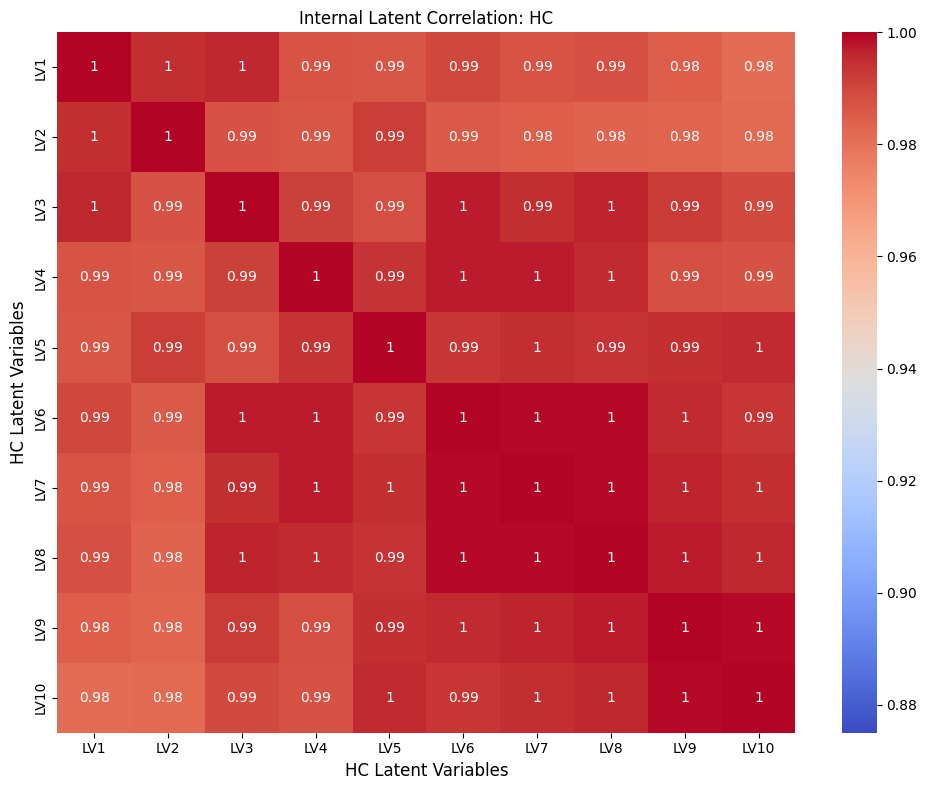

In [ ]:
unique_encoders = latent_space_comb['encoder'].unique()
encoder_pairs = list(product(unique_encoders, repeat=2))
for enc1, enc2 in encoder_pairs:
    z1 = latent_space_comb[latent_space_comb['encoder'] == enc1].iloc[:, :latent_dim]
    z2 = latent_space_comb[latent_space_comb['encoder'] == enc2].iloc[:, :latent_dim]
    
    if len(z1) != len(z2):
        print(f"Skipping {enc1} vs {enc2} due to row count mismatch.")
        continue

    stacked = np.hstack((z1, z2))
    full_corr = np.corrcoef(stacked.T)
    cross_corr = full_corr[:latent_dim, latent_dim:]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cross_corr, 
        annot=True, 
        cmap='coolwarm', 
        xticklabels=latent_cols,
        yticklabels=latent_cols, 
        vmin=0.875, 
        vmax=1
    )
    
    plt.xlabel(f"{enc2} Latent Variables", fontsize=12)
    plt.ylabel(f"{enc1} Latent Variables", fontsize=12)
    if enc1 == enc2:
        plt.title(f"Internal Latent Correlation: {enc1}")
    else:
        plt.title(f"Cross-Modal Latent Correlation: {enc1} vs {enc2}")
    plt.tight_layout()
    plt.show()
    if enc1 == enc2:
        plt.savefig(os.path.join(output_folder, f"InternalLatentCorrelation:{enc1}.png"))
    else:
        plt.savefig(os.path.join(output_folder, f"Cross-ModalLatentCorrelation:{enc1}vs{enc2}.png"))